#CNN Con Aumento de imagenes y dropout

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow.keras.utils import to_categorical

#Cargar los datos de MNIST
#Aqui lo hago de otra manera porque es mas simple para poder usar el modulo de aumento de datos
#de Keras de esta manera
(X_entrenamiento, Y_entrenamiento), (X_pruebas, Y_pruebas) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Colocar los datos en la forma correcta que ya hemos visto (1, 28, 28, 1)
X_entrenamiento = X_entrenamiento.reshape(X_entrenamiento.shape[0], 28, 28, 1)
X_pruebas = X_pruebas.reshape(X_pruebas.shape[0], 28, 28, 1)

#Hacer 'one-hot encoding' de los resultados (e.g. en lugar de tener como resultado una sola neurona, tendre 10 donde solo el resultado correcto sera 1 y el resto 0)
Y_entrenamiento = to_categorical(Y_entrenamiento)
Y_pruebas = to_categorical(Y_pruebas)

#Convertir a flotante y normalizar para que aprenda mejor la red
X_entrenamiento = X_entrenamiento.astype('float32') / 255
X_pruebas = X_pruebas.astype('float32') / 255

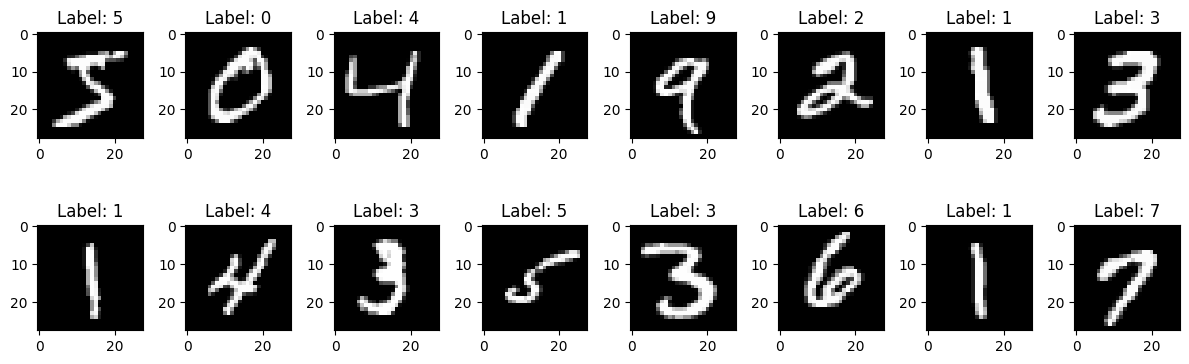

In [ ]:
#Codigo para mostrar imagenes del set, no es necesario ejecutarlo, solo imprime unos numeros :)
import matplotlib.pyplot as plt
filas = 2
columnas = 8
num = filas*columnas
imagenes = X_entrenamiento[0:num]
etiquetas = Y_entrenamiento[0:num]
fig, axes = plt.subplots(filas, columnas, figsize=(1.5*columnas,2*filas))
for i in range(num):
     ax = axes[i//columnas, i%columnas]
     ax.imshow(imagenes[i].reshape(28,28), cmap='gray')
     ax.set_title('Label: {}'.format(np.argmax(etiquetas[i])))
plt.tight_layout()
plt.show()

**rotation_range:** Especifica el rango de ángulos en grados para rotar aleatoriamente las imágenes. En este caso, se permiten rotaciones en un rango de -30 a +30 grados.

**width_shift_range y height_shift_range:** Indican el rango fraccionario (en proporción de la dimensión de la imagen) para desplazar horizontalmente y verticalmente las imágenes, respectivamente. Aquí, se permite un desplazamiento máximo de ±0.25 en ambas direcciones.

**zoom_range:** Especifica el rango de factores de zoom aleatorios que se aplicarán a las imágenes. En este caso, se permiten zooms aleatorios en un rango de 0.5 a 1.5 veces el tamaño original de la imagen.

**shear_range:** Indica el rango de ángulos en grados para aplicar deformaciones de cizallamiento a las imágenes.


In [ ]:
#Aumento de datos
#Variables para controlar las transformaciones que se haran en el aumento de datos
#utilizando ImageDataGenerator de keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rango de transformaciones
rango_rotacion = 30
mov_ancho = 0.2
mov_alto = 0.2
rango_inclinacion = 10
rango_acercamiento = [0.8, 1]

# Crear el generador
datagen = ImageDataGenerator(
    rotation_range=rango_rotacion,
    width_shift_range=mov_ancho,
    height_shift_range=mov_alto,
    zoom_range=rango_acercamiento,
    shear_range=rango_inclinacion
)

# Ajustar el generador a los datos de entrenamiento
datagen.fit(X_entrenamiento)


In [ ]:
len(X_entrenamiento)

60000

ANTES:



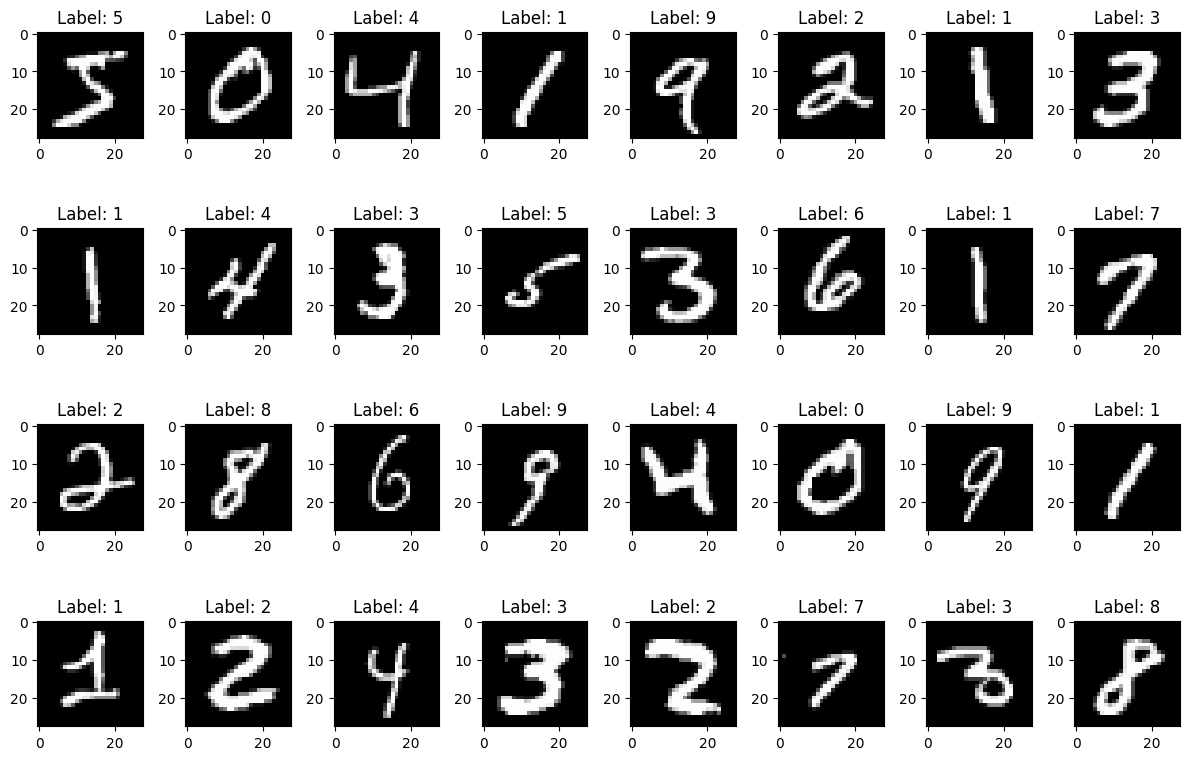

In [ ]:
# Código para mostrar imágenes antes y después de las transformaciones
filas = 4
columnas = 8
num = filas * columnas

print('ANTES:\n')
fig1, axes1 = plt.subplots(filas, columnas, figsize=(1.5*columnas, 2*filas))
for i in range(num):
    ax = axes1[i // columnas, i % columnas]
    ax.imshow(X_entrenamiento[i].reshape(28, 28), cmap='gray')
    ax.set_title('Label: {}'.format(np.argmax(Y_entrenamiento[i])))
plt.tight_layout()
plt.show()


DESPUES:



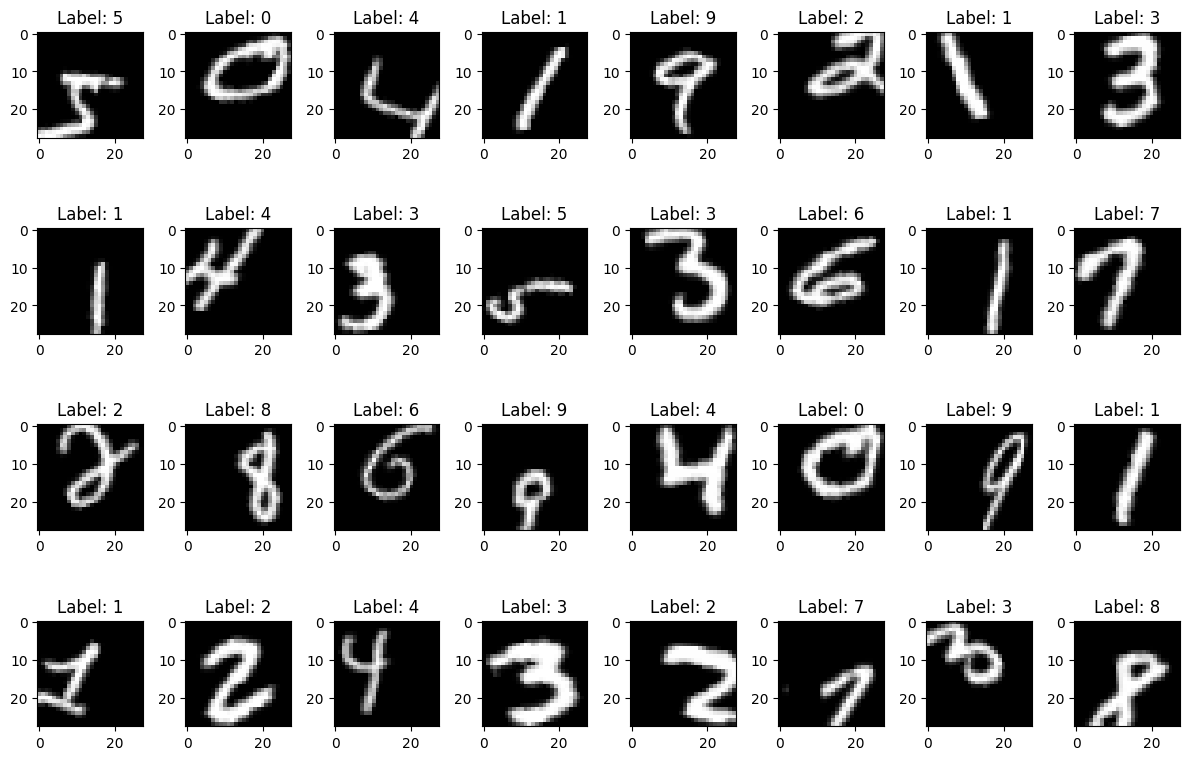

In [ ]:
print('DESPUES:\n')
fig2, axes2 = plt.subplots(filas, columnas, figsize=(1.5 * columnas, 2 * filas))
for X, Y in datagen.flow(X_entrenamiento, Y_entrenamiento.reshape(Y_entrenamiento.shape[0], 10), batch_size=num, shuffle=False):
    for i in range(num):
        ax = axes2[i // columnas, i % columnas]
        ax.imshow(X[i].reshape(28, 28), cmap='gray')
        ax.set_title('Label: {}'.format(int(np.argmax(Y[i]))))
    break
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# Modelo
modelo = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),  # Regulariza la parte convolucional

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(10, activation='softmax')  # Capa de salida
])

# Compilación
modelo.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
TAMANO_LOTE = 32

#Entrenar la red. Toma un buen rato! Ve por un café ;)
#Oye suscribete al canal!
print("Entrenando modelo...");
epocas=100
history = modelo.fit(
    datagen.flow(X_entrenamiento, Y_entrenamiento, batch_size=TAMANO_LOTE ),
    epochs=100,
    validation_data=(X_pruebas, Y_pruebas),
    steps_per_epoch=len(X_entrenamiento) // TAMANO_LOTE,
    callbacks=[early_stopping]
)

print("Modelo entrenado!");

Entrenando modelo...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.4104 - loss: 1.6503 - val_accuracy: 0.9410 - val_loss: 0.2139
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7906 - loss: 0.6767 - val_accuracy: 0.9607 - val_loss: 0.1321
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8462 - loss: 0.5111 - val_accuracy: 0.9707 - val_loss: 0.0986
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8645 - loss: 0.4516 - val_accuracy: 0.9657 - val_loss: 0.1180
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8777 - loss: 0.4102 - val_accuracy: 0.9712 - val_loss: 0.1003
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8848 - loss: 0.3924 - val_accuracy: 0.9744 - val_loss: 0.0821
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8933 - loss: 0.3657 - val_accuracy: 0.9682 - val_loss: 0.1012
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8945 - los

In [ ]:
# Guardar el modelo en el formato nativo de Keras
modelo.save('numerosC3.keras')
#modelo.save('numerosC3.h5')

#Modelo.to_json()
Convierte la arquitectura del modelo a una representación en formato JSON. El JSON (JavaScript Object Notation) es un formato de texto ligero y fácilmente legible por humanos que describe la estructura del modelo, pero no guarda los pesos ni el estado de entrenamiento (como la información de las capas, las conexiones, la estructura de la red, etc.).
Este archivo JSON solo contiene la estructura del modelo: capas, configuraciones, funciones de activación, etc.


**Portabilidad:** Si deseas compartir solo la estructura del modelo (sin los pesos) con alguien o guardarla para futuros usos, puedes guardar el modelo en formato JSON. Luego, puedes reconstruir la arquitectura del modelo cargando el archivo JSON en cualquier entorno compatible.

**Modificaciones**: Si deseas modificar o ajustar solo la estructura del modelo (por ejemplo, agregar más capas), puedes hacer cambios en el JSON y luego cargarlo para crear una nueva versión del modelo.

**Independencia del entrenamiento:** Guardar el modelo como JSON es útil si solo te interesa compartir la estructura y no los pesos entrenados.




In [ ]:
model_json = modelo.to_json()
with open('numerosC.json', 'w') as json_file:
    json_file.write(model_json)
modelo.save_weights('numerosC.weights.h5')

#Guardar los pesos del modelo en un archivo HDF5 (modelo.save_weights('numerosC.weights.h5'))

 guarda solo los pesos del modelo en un archivo en formato HDF5. Este formato se usa comúnmente para almacenar datos numéricos (como matrices de pesos) y puede manejar grandes volúmenes de datos (en este caso, los pesos entrenados de tu red neuronal).

Los pesos son los valores que se aprenden durante el proceso de entrenamiento, y se utilizan para realizar las predicciones una vez que el modelo ha sido entrenado.


**Guardar solo los pesos:** Si solo deseas guardar los pesos del modelo para luego usarlos en la misma arquitectura (es decir, en el mismo tipo de red), puedes guardar los pesos por separado, mientras que la arquitectura se puede cargar a partir del archivo JSON. Luego, puedes cargar los pesos en el modelo con model.load_weights() en cualquier momento.


**Menor tamaño:** Si ya tienes el modelo en un formato JSON y solo necesitas almacenar los pesos (que suelen ser los datos más grandes), guardar solo los pesos en HDF5 puede ser más eficiente en cuanto a almacenamiento.
Uso compartido: Puedes compartir los pesos entrenados con otros sin necesidad de compartir la arquitectura completa del modelo (aunque esto es menos común, ya que la estructura también es importante).





```python

# Recuperar la arquitectura del modelo:

from tensorflow.keras.models import model_from_json

# Cargar la arquitectura del modelo desde el archivo JSON
with open('numerosC.json', 'r') as json_file:
    model_json = json_file.read()
modelo_cargado = model_from_json(model_json)

# Recuperar los pesos:

# Cargar los pesos entrenados desde el archivo HDF5
modelo_cargado.load_weights('numerosC.weights.h5')

```

In [ ]:
#Exportar el modelo al explorador! (Mas detalle de esto en en mi video de exportacion: https://youtu.be/JpE4bYyRADI )
#modelo.save('numeros_conv_ad_do.h5')

#Convertirlo a tensorflow.js
#!pip install tensorflowjs

#!mkdir carpeta_salida

#!tensorflowjs_converter --input_format keras numeros_conv_ad_do.h5 carpeta_salida

## Preprocesamiento de la imagen

In [ ]:
import requests
from PIL import Image
import numpy as np

# Download the image
image_url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/numero7a.jpg"
response = requests.get(image_url, stream=True)
response.raise_for_status() # Raise an exception for bad status codes

# Open the image
img = Image.open(response.raw)

# Convert to grayscale
img_gray = img.convert('L')

# Resize the image
img_resized = img_gray.resize((28, 28))

# Convert to numpy array
img_array = np.array(img_resized)

# Normalize the image
img_normalized = img_array / 255.0

# Expand dimensions to match model input shape (batch size, height, width, channels)
img_final = np.expand_dims(img_normalized, axis=0)
img_final = np.expand_dims(img_final, axis=-1)

print("Image preprocessed successfully.")
print(f"Shape of the preprocessed image: {img_final.shape}")

Image preprocessed successfully.
Shape of the preprocessed image: (1, 28, 28, 1)


## Predecir el digito

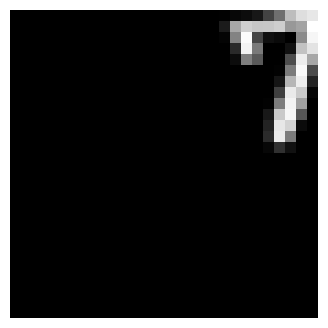

In [ ]:
#ver la image cargda
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(img_final[0, :, :, 0], cmap='gray')
plt.axis('off')
plt.show()

## Desplegamos la predicción


In [ ]:
# Load the trained model
modelo_cargado = tf.keras.models.load_model('numerosC3.keras')

# Make a prediction
predicciones = modelo_cargado.predict(img_final)

# Get the predicted class index
predicted_class_index = np.argmax(predicciones[0])

print(f"Predicted class probabilities: {predicciones[0]}")
print(f"Predicted digit: {predicted_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
Predicted class probabilities: [1.2377574e-03 1.1773434e-02 8.7561570e-02 5.2258070e-03 7.1007048e-04
 1.3668260e-04 1.5666524e-06 8.8627714e-01 2.7954153e-04 6.7964201e-03]
Predicted digit: 7


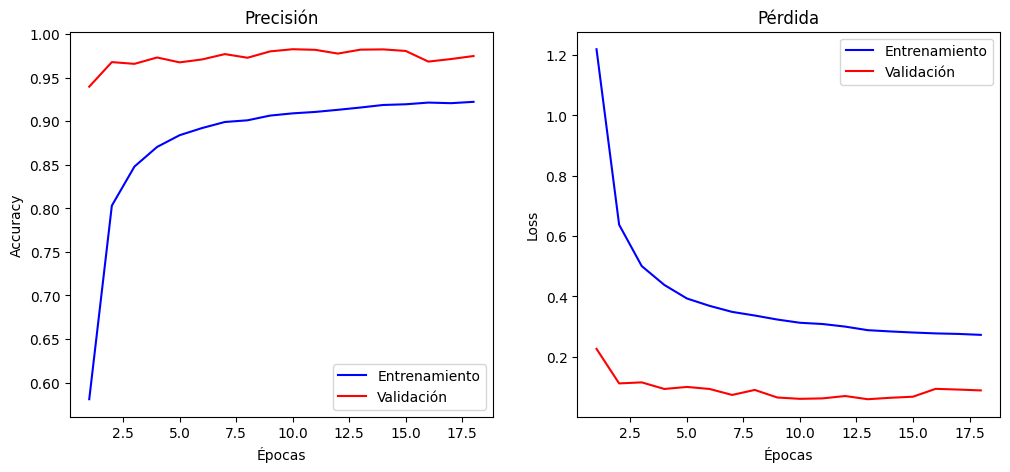

In [ ]:
# Extraer métricas del historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epocas = range(1, len(acc) + 1)

# Gráfica de precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento')
plt.plot(epocas, val_acc, 'r-', label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento')
plt.plot(epocas, val_loss, 'r-', label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()